In [1]:
from database.adatabase import ADatabase
import pandas as pd
from modeler.modeler import Modeler as m
import matplotlib.pyplot as plt
from processor.processor import Processor as processor
from xgboost.sklearn import XGBRegressor
from tqdm import tqdm
import warnings
warnings.simplefilter(action="ignore")
import pickle
from datetime import datetime, timedelta, timezone

In [2]:
db = ADatabase("algo")
market = ADatabase("market")
fed = ADatabase("fed")
market.connect()
sp100 = market.retrieve("sp100")
market.disconnect()

In [3]:
sp100

,ticker,GICS Sector,cik
0,AAPL,Information Technology,320193
1,ABBV,Health Care,1551152
2,ABT,Health Care,1800
3,ACN,Information Technology,1467373
4,ADBE,Information Technology,796343
...,...,...,...
96,V,Information Technology,1403161
97,VZ,Communication Services,732712
98,WFC,Financials,72971
99,WMT,Consumer Staples,104169


In [ ]:
holding_period = 65
tickers = sp100["ticker"].values
factors = ["assets","liabilities","stockholdersequity","adjclose"] + ["rolling_" + str(i) for i in [5,10,20,60,100]]
positions = len(sp100["GICS Sector"].unique())
training_year = 2020
training_years = 4

In [ ]:
market.connect()
model = XGBRegressor(booster="gbtree",objective ='reg:squarederror', colsample_bytree = 0.3, learning_rate = 0.1,
                        max_depth = 5, alpha = 10, n_estimators = 100,  verbosity=0,refit=False)
for ticker in tqdm(tickers,desc="model_prep"):
    try:
        cik = sp100[sp100["ticker"]==ticker]["cik"].item()
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))
        filings = market.query("filings",{"cik":cik})
        ticker_prices.sort_values("date",inplace=True)
        ticker_prices = processor.merge(ticker_prices,filings,["year","quarter"]).ffill()
        for days in [5,10,20,60,100]:
            ticker_prices[f"rolling_{days}"] = ticker_prices["adjclose"].rolling(window=days).mean() 
        ticker_prices["y"] = ticker_prices["adjclose"].shift(-holding_period)
        model_data = ticker_prices[(ticker_prices["year"]<=training_year) & (ticker_prices["year"]>=training_year-training_years)].dropna().reset_index(drop=True)
        model.fit(model_data[factors],model_data["y"])
    except Exception as e:
        print(str(e))
        continue
market.disconnect()

In [6]:
market.connect()
prices = []
for ticker in tqdm(tickers,desc="model_prep"):
    try:
        cik = sp100[sp100["ticker"]==ticker]["cik"].item()
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))
        filings = market.query("filings",{"cik":cik})
        ticker_prices.sort_values("date",inplace=True)
        ticker_prices = processor.merge(ticker_prices,filings,["year","quarter"]).ffill()
        for days in [5,10,20,60,100]:
            ticker_prices[f"rolling_{days}"] = ticker_prices["adjclose"].rolling(window=days).mean() 
        simulation = ticker_prices[(ticker_prices["year"]>training_year)].reset_index(drop=True)
        simulation["prediction"] = model.predict(simulation[factors])
        simulation.sort_values("date",inplace=True)
        simulation["predicted_return"] = (simulation["prediction"] - simulation["adjclose"]) / simulation["adjclose"]
        simulation["signal"] = simulation["predicted_return"]
        simulation["buy_price"] = simulation["adjclose"].shift(-1)
        simulation["buy_date"] = simulation["date"].shift(-1)
        simulation["sell_price"] = simulation["adjclose"].shift(-holding_period)
        simulation["sell_date"] = simulation["date"].shift(-holding_period)
        simulation["abs"] = simulation["signal"].abs()
        simulation["direction"] = simulation["signal"] / simulation["abs"] * -1
        simulation["return"] = (simulation["sell_price"] - simulation["buy_price"]) / simulation ["buy_price"] * (1/positions) * simulation["direction"]
        prices.append(simulation)
    except Exception as e:
        print(str(e))
        continue
market.disconnect()

model_prep:  20%|████████████████████████████                                                                                                                  | 20/101 [00:03<00:10,  7.56it/s]

'date'


model_prep: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:19<00:00,  5.22it/s]


In [7]:
simulation

,date,adjclose,ticker,year,quarter,month,week,weekday,adsh,assets,...,prediction,predicted_return,signal,buy_price,buy_date,sell_price,sell_date,abs,direction,return
0,2021-01-04 00:00:00+00:00,36.350778,XOM,2021,1,1,1,0,0000034088-21-000012,3.471810e+11,...,49.732437,0.368126,0.368126,38.102623,2021-01-05 00:00:00+00:00,49.894531,2021-04-08 00:00:00+00:00,0.368126,-1.0,-0.028134
1,2021-01-05 00:00:00+00:00,38.102623,XOM,2021,1,1,1,1,0000034088-21-000012,3.471810e+11,...,49.427006,0.297207,0.297207,39.074897,2021-01-06 00:00:00+00:00,49.778705,2021-04-09 00:00:00+00:00,0.297207,-1.0,-0.024903
2,2021-01-06 00:00:00+00:00,39.074897,XOM,2021,1,1,1,2,0000034088-21-000012,3.471810e+11,...,49.427006,0.264930,0.264930,39.381470,2021-01-07 00:00:00+00:00,49.449044,2021-04-12 00:00:00+00:00,0.264930,-1.0,-0.023240
3,2021-01-07 00:00:00+00:00,39.381470,XOM,2021,1,1,1,3,0000034088-21-000012,3.471810e+11,...,49.427006,0.255083,0.255083,39.819431,2021-01-08 00:00:00+00:00,49.636149,2021-04-13 00:00:00+00:00,0.255083,-1.0,-0.022412
4,2021-01-08 00:00:00+00:00,39.819431,XOM,2021,1,1,1,4,0000034088-21-000012,3.471810e+11,...,49.427006,0.241279,0.241279,41.028204,2021-01-11 00:00:00+00:00,51.070617,2021-04-14 00:00:00+00:00,0.241279,-1.0,-0.022252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
729,2023-11-27 00:00:00+00:00,103.960000,XOM,2023,4,11,48,0,0000034088-23-000048,3.661575e+11,...,44.844383,-0.568638,-0.568638,103.900000,2023-11-28 00:00:00+00:00,NaN,NaT,0.568638,1.0,NaN
730,2023-11-28 00:00:00+00:00,103.900000,XOM,2023,4,11,48,1,0000034088-23-000048,3.661575e+11,...,44.844383,-0.568389,-0.568389,102.340000,2023-11-29 00:00:00+00:00,NaN,NaT,0.568389,1.0,NaN
731,2023-11-29 00:00:00+00:00,102.340000,XOM,2023,4,11,48,2,0000034088-23-000048,3.661575e+11,...,44.844383,-0.561810,-0.561810,102.740000,2023-11-30 00:00:00+00:00,NaN,NaT,0.561810,1.0,NaN
732,2023-11-30 00:00:00+00:00,102.740000,XOM,2023,4,11,48,3,0000034088-23-000048,3.661575e+11,...,44.844383,-0.563516,-0.563516,102.990000,2023-12-01 00:00:00+00:00,NaN,NaT,0.563516,1.0,NaN


In [8]:
sim = pd.concat(prices).reset_index(drop=True)
sim.sort_values("date",inplace=True)
sim = processor.merge(sim,sp100,on="ticker")

In [9]:
## backtest
trades = sim[sim["weekday"]==4]
trades = trades[trades["direction"]==1]
trades = trades[trades["week"] % int(holding_period/5) == 0]
trades = trades.sort_values("abs",ascending=False).groupby(["date","GICS Sector"]).first().reset_index()

In [10]:
trades = processor.column_date_processing(trades[["date","abs","direction","ticker","GICS Sector","adjclose","return"]])

In [11]:
portfolio = trades[["date","return"]].groupby("date").sum().reset_index()
portfolio.sort_values("date",inplace=True)
portfolio = portfolio[portfolio["date"]<portfolio["date"].max()]
portfolio["return"] = portfolio["return"] + 1
portfolio["cr"] = portfolio["return"].cumprod()

In [12]:
fed.connect()
bench = fed.retrieve("sp500")
fed.disconnect()
bench["date"] = pd.to_datetime(bench["date"],utc=True)
bench["value"] = [float(x) for x in bench["value"]]
portfolio = processor.column_date_processing(portfolio)
portfolio = processor.merge(portfolio,bench,on="date")
portfolio.dropna(inplace=True)
portfolio["bcr"] = (portfolio["value"] - portfolio["value"].iloc[0]) / portfolio["value"].iloc[0] + 1

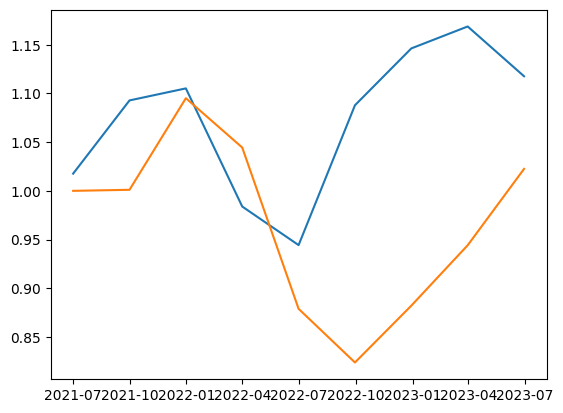

In [13]:
plt.plot(portfolio["date"].values,portfolio["cr"].values)
plt.plot(portfolio["date"].values,portfolio["bcr"].values)
plt.show()

In [14]:
recommendations = trades.tail(positions)

In [15]:
recommendations

,date,abs,direction,ticker,gics sector,adjclose,return,year,quarter,month,week,weekday
99,2023-09-29 00:00:00+00:00,0.886024,1.0,CHTR,Communication Services,439.820000,NaN,2023,3,9,39,4
100,2023-09-29 00:00:00+00:00,0.980782,1.0,BKNG,Consumer Discretionary,3083.950000,NaN,2023,3,9,39,4
101,2023-09-29 00:00:00+00:00,0.894904,1.0,COST,Consumer Staples,563.925405,NaN,2023,3,9,39,4
102,2023-09-29 00:00:00+00:00,0.644778,1.0,CVX,Energy,166.842947,NaN,2023,3,9,39,4
103,2023-09-29 00:00:00+00:00,0.908326,1.0,BLK,Financials,646.490000,NaN,2023,3,9,39,4
104,2023-09-29 00:00:00+00:00,0.906500,1.0,LLY,Health Care,536.138159,NaN,2023,3,9,39,4
105,2023-09-29 00:00:00+00:00,0.854061,1.0,LMT,Industrials,406.103121,NaN,2023,3,9,39,4
106,2023-09-29 00:00:00+00:00,0.928645,1.0,AVGO,Information Technology,830.580000,NaN,2023,3,9,39,4
107,2023-09-29 00:00:00+00:00,0.840339,1.0,LIN,Materials,371.200424,NaN,2023,3,9,39,4
108,2023-09-29 00:00:00+00:00,0.635927,1.0,AMT,Real Estate,162.786815,NaN,2023,3,9,39,4


In [16]:
db.connect()
db.drop('portfolios')
db.drop('trades')
db.drop('recommendations')
db.store("portfolio",portfolio)
db.store("trades",trades)
db.store("recommendations",recommendations)
db.disconnect()